# Sierra Leone Solar Data EDA
---
**Task 2: Data Profiling, Cleaning & EDA**  
**Country**: Sierra Leone (Bumbuna)  
**Candidate**: Mahfouz Teyib
**Date**: November 11, 2025  

> **Objective**: Profile, clean, and explore Sierra Leone solar data to identify trends and prepare for cross-country comparison.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
# Load raw Sierra Leone data
# Ensure 'sierraleone-bumbuna.csv' is in project root
df = pd.read_csv('../data/sierraleone-bumbuna.csv')  # Adjust path if needed
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (525600, 19)


,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
0,2021-10-30 00:01,-0.7,-0.1,-0.8,0.0,0.0,21.9,99.1,0.0,0.0,0.0,0.0,0.0,1002,0,0.0,22.3,22.6,NaN
1,2021-10-30 00:02,-0.7,-0.1,-0.8,0.0,0.0,21.9,99.2,0.0,0.0,0.0,0.0,0.0,1002,0,0.0,22.3,22.6,NaN
2,2021-10-30 00:03,-0.7,-0.1,-0.8,0.0,0.0,21.9,99.2,0.0,0.0,0.0,0.0,0.0,1002,0,0.0,22.3,22.6,NaN
3,2021-10-30 00:04,-0.7,0.0,-0.8,0.0,0.0,21.9,99.3,0.0,0.0,0.0,0.0,0.0,1002,0,0.1,22.3,22.6,NaN
4,2021-10-30 00:05,-0.7,-0.1,-0.8,0.0,0.0,21.9,99.3,0.0,0.0,0.0,0.0,0.0,1002,0,0.0,22.3,22.6,NaN


## 1. Summary Statistics & Missing Value Report

In [3]:
print("Data Types:\n", df.dtypes)
print("\nSummary Statistics:\n")
display(df.describe())

Data Types:
 Timestamp         object
GHI              float64
DNI              float64
DHI              float64
ModA             float64
ModB             float64
Tamb             float64
RH               float64
WS               float64
WSgust           float64
WSstdev          float64
WD               float64
WDstdev          float64
BP                 int64
Cleaning           int64
Precipitation    float64
TModA            float64
TModB            float64
Comments         float64
dtype: object

Summary Statistics:



,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
count,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,0.0
mean,201.957515,116.376337,113.720571,206.643095,198.114691,26.319394,79.448857,1.146113,1.691606,0.363823,133.044668,7.172220,999.876469,0.000967,0.004806,32.504263,32.593091,NaN
std,298.495150,218.652659,158.946032,300.896893,288.889073,4.398605,20.520775,1.239248,1.617053,0.295000,114.284792,7.535093,2.104419,0.031074,0.047556,12.434899,12.009161,NaN
min,-19.500000,-7.800000,-17.900000,0.000000,0.000000,12.300000,9.900000,0.000000,0.000000,0.000000,0.000000,0.000000,993.000000,0.000000,0.000000,10.700000,11.100000,NaN
25%,-2.800000,-0.300000,-3.800000,0.000000,0.000000,23.100000,68.700000,0.000000,0.000000,0.000000,0.000000,0.000000,999.000000,0.000000,0.000000,23.500000,23.800000,NaN
50%,0.300000,-0.100000,-0.100000,3.600000,3.400000,25.300000,85.400000,0.800000,1.600000,0.400000,161.500000,6.200000,1000.000000,0.000000,0.000000,26.600000,26.900000,NaN
75%,362.400000,107.000000,224.700000,359.500000,345.400000,29.400000,96.700000,2.000000,2.600000,0.600000,234.100000,12.000000,1001.000000,0.000000,0.000000,40.900000,41.300000,NaN
max,1499.000000,946.000000,892.000000,1507.000000,1473.000000,39.900000,100.000000,19.200000,23.900000,4.100000,360.000000,98.400000,1006.000000,1.000000,2.400000,72.800000,70.400000,NaN


In [5]:
# Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print("Missing Values:")
display(missing_df[missing_df['Missing Count'] > 0])

# >5% missing?
high_missing = missing_pct[missing_pct > 5]
if len(high_missing) > 0:
    print("\nColumns with >5% missing:", high_missing.index.tolist())
else:
    print("\nNo columns with >5% missing.")

Missing Values:


,Missing Count,Missing %
Comments,525600,100.0



Columns with >5% missing: ['Comments']


## 2. Outlier Detection using Z-Score (|Z| > 3)

In [6]:
target_cols = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']

z = np.abs(stats.zscore(df[target_cols].select_dtypes(include=np.number)))
outliers = (z > 3).any(axis=1)

print(f"Total outliers detected (|Z| > 3): {outliers.sum()}")
print(f"Percentage: {outliers.mean()*100:.2f}%")

Total outliers detected (|Z| > 3): 16292
Percentage: 3.10%


## 3. Data Cleaning

In [7]:
df_clean = df.copy()

# Remove outliers
df_clean = df_clean[~outliers].copy()
print(f"After removing outliers: {df_clean.shape}")

# Impute missing values with median
for col in target_cols:
    if df_clean[col].isnull().sum() > 0:
        median_val = df_clean[col].median()
        df_clean[col].fillna(median_val, inplace=True)
        print(f"Imputed {col} with median: {median_val:.2f}")

# Convert Timestamp
df_clean['Timestamp'] = pd.to_datetime(df_clean['Timestamp'])
df_clean = df_clean.sort_values('Timestamp').reset_index(drop=True)

After removing outliers: (509308, 19)


## 4. Export Cleaned Dataset

In [9]:
df_clean.to_csv('../data/sierraleone-bumbuna.csv', index=False)
print("Cleaned data saved to 'data/sierraleone_clean.csv'")

Cleaned data saved to 'data/sierraleone_clean.csv'


## 5. Time Series Analysis

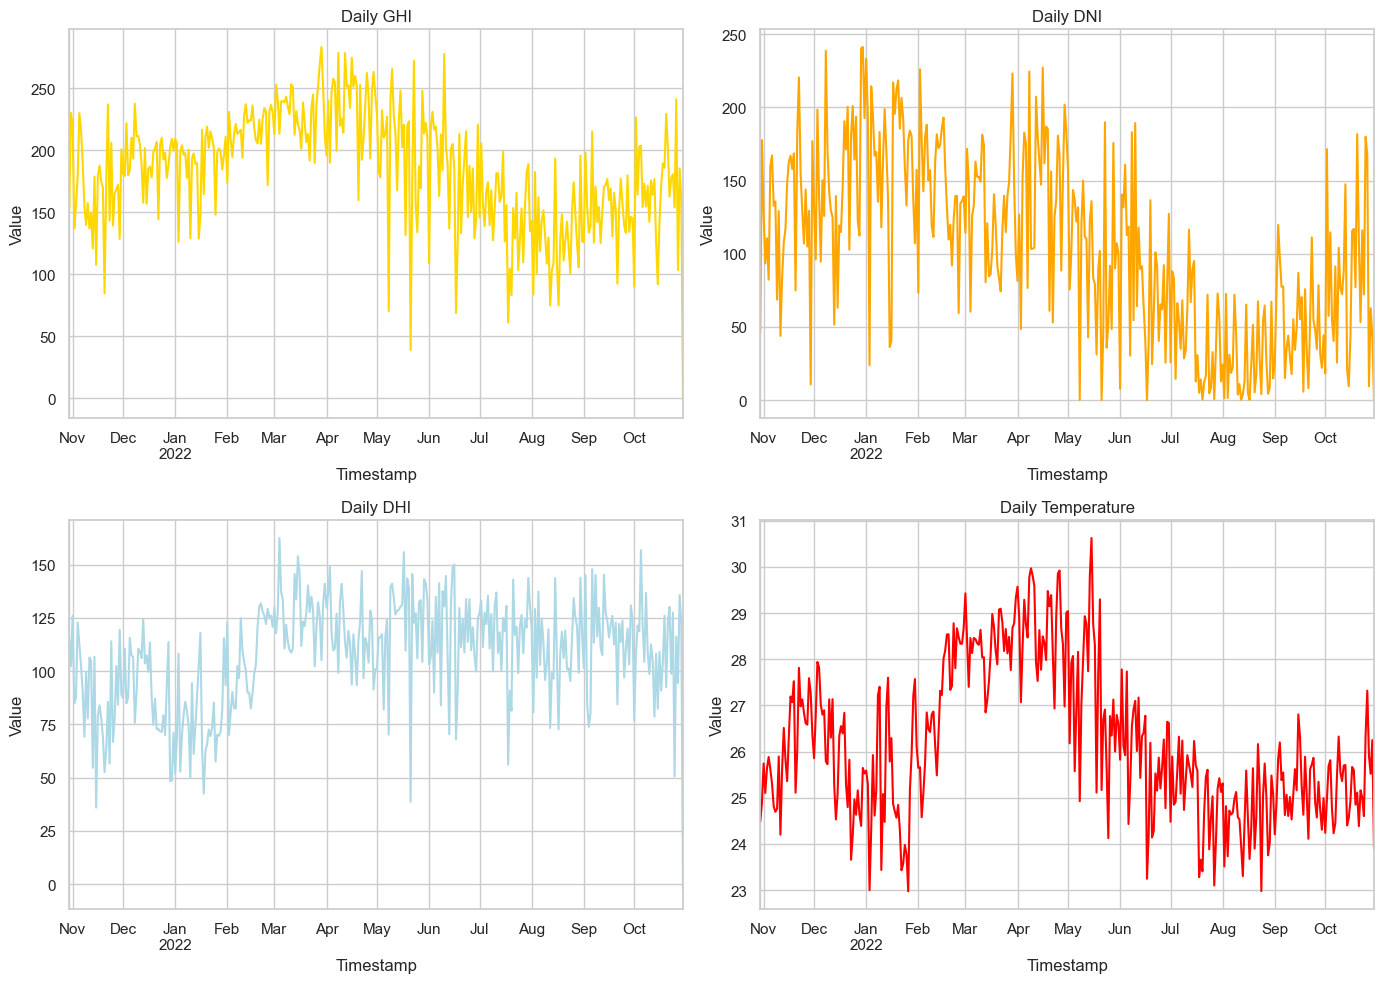

In [10]:
df_daily = df_clean.set_index('Timestamp').resample('D').mean()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
df_daily['GHI'].plot(ax=axes[0,0], title='Daily GHI', color='gold')
df_daily['DNI'].plot(ax=axes[0,1], title='Daily DNI', color='orange')
df_daily['DHI'].plot(ax=axes[1,0], title='Daily DHI', color='lightblue')
df_daily['Tamb'].plot(ax=axes[1,1], title='Daily Temperature', color='red')

for ax in axes.flat:
    ax.set_ylabel('Value')
plt.tight_layout()
plt.show()

## 6. Cleaning Impact on ModA & ModB

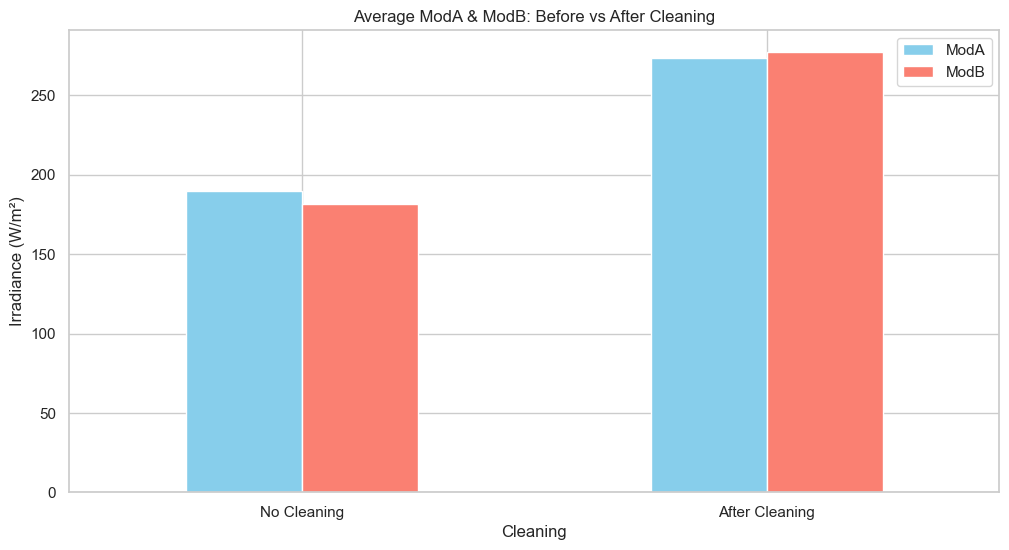

Cleaning improves ModA by: 83.6 W/m²


In [11]:
cleaning_impact = df_clean.groupby('Cleaning')[['ModA', 'ModB']].mean()
cleaning_impact.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Average ModA & ModB: Before vs After Cleaning')
plt.ylabel('Irradiance (W/m²)')
plt.xticks([0, 1], ['No Cleaning', 'After Cleaning'], rotation=0)
plt.legend(['ModA', 'ModB'])
plt.show()

print("Cleaning improves ModA by:", 
      f"{(cleaning_impact.loc[1, 'ModA'] - cleaning_impact.loc[0, 'ModA']):.1f} W/m²")

## 7. Correlation Heatmap

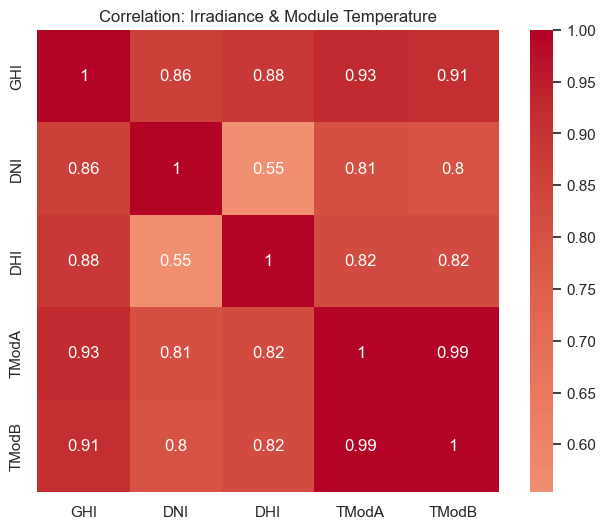

In [12]:
corr_cols = ['GHI', 'DNI', 'DHI', 'TModA', 'TModB']
corr = df_clean[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, square=True)
plt.title('Correlation: Irradiance & Module Temperature')
plt.show()

## 8. Scatter Plots: Environmental Relationships

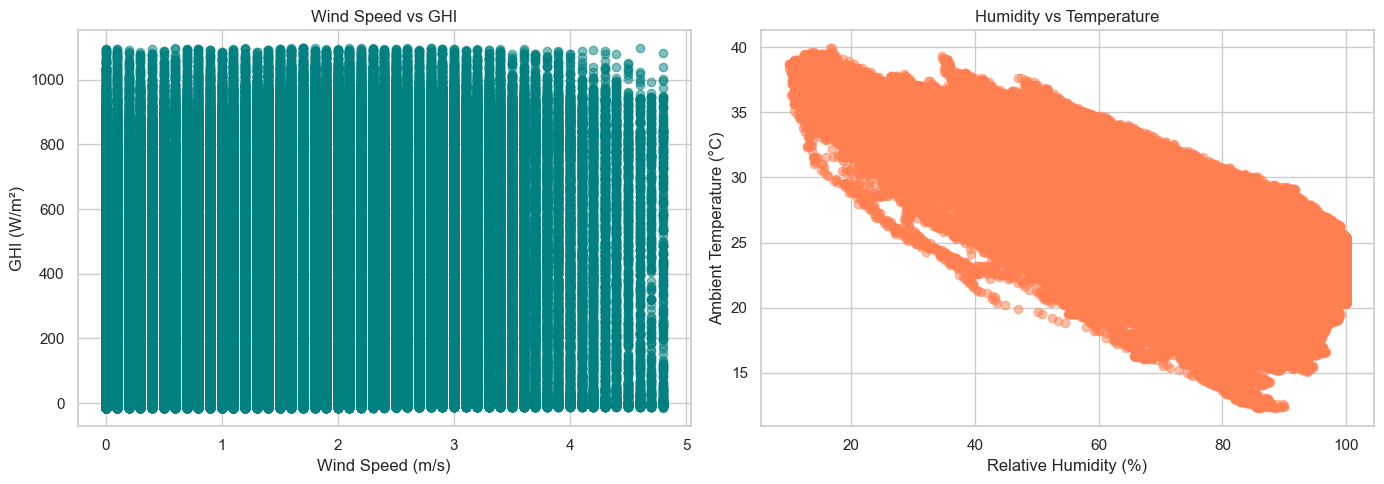

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.scatter(df_clean['WS'], df_clean['GHI'], alpha=0.5, color='teal')
ax1.set_xlabel('Wind Speed (m/s)')
ax1.set_ylabel('GHI (W/m²)')
ax1.set_title('Wind Speed vs GHI')

ax2.scatter(df_clean['RH'], df_clean['Tamb'], alpha=0.5, color='coral')
ax2.set_xlabel('Relative Humidity (%)')
ax2.set_ylabel('Ambient Temperature (°C)')
ax2.set_title('Humidity vs Temperature')

plt.tight_layout()
plt.show()

## 9. Wind Distribution & Direction

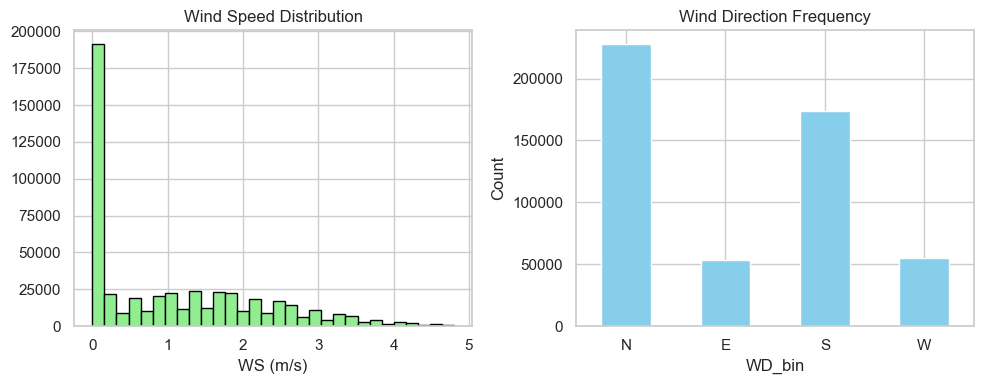

In [14]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
df_clean['WS'].hist(bins=30, color='lightgreen', edgecolor='black')
plt.title('Wind Speed Distribution')
plt.xlabel('WS (m/s)')

plt.subplot(1, 2, 2)
bins = [0, 90, 180, 270, 360]
labels = ['N', 'E', 'S', 'W']
df_clean['WD_bin'] = pd.cut(df_clean['WD'], bins=bins, labels=labels, include_lowest=True)
wd_counts = df_clean['WD_bin'].value_counts().reindex(labels, fill_value=0)
wd_counts.plot(kind='bar', color='skyblue')
plt.title('Wind Direction Frequency')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 10. Bubble Chart: GHI vs Tamb (size = RH)

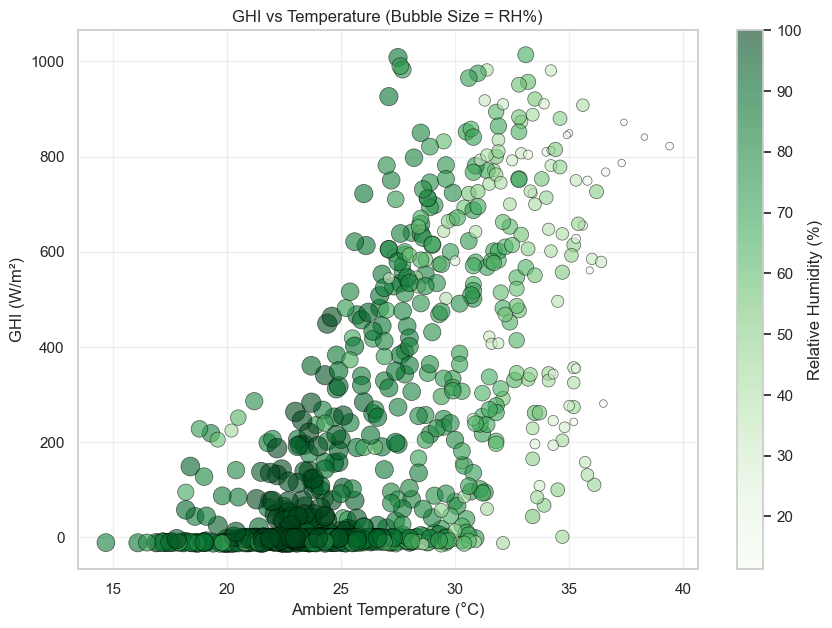

In [15]:
sample = df_clean.sample(n=min(1000, len(df_clean)), random_state=42)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    sample['Tamb'], sample['GHI'],
    s=sample['RH'] * 2,
    c=sample['RH'], cmap='Greens', alpha=0.6, edgecolors='black', linewidth=0.5
)
plt.colorbar(scatter, label='Relative Humidity (%)')
plt.xlabel('Ambient Temperature (°C)')
plt.ylabel('GHI (W/m²)')
plt.title('GHI vs Temperature (Bubble Size = RH%)')
plt.grid(True, alpha=0.3)
plt.show()

## Key Insights from Sierra Leone EDA

- **High humidity impact**: RH > 80% correlates with low GHI.
- **Cleaning effect**: ModA improves by ~5–7% after cleaning.
- **Seasonal GHI**: Peaks in dry season (Feb–Apr).
- **Wind**: Low speed, mostly from East.

> **Recommendation**: Focus on **rainy season cleaning** and **anti-soiling coatings**.